# Reverse Curriculum: Task Feature vs Policy Effect

This notebook uses reusable X/Y builders from `experiments.analysis.policy_xy_builders`:
- **Y**: task-level paired effect (`delta = compare - baseline`)
- **X**: task-level baseline feature (`X_FEATURE`)

No binning or median split; output is scatter + correlation + optional trendline + optional CSV export.


In [38]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


REPO_ROOT = Path('/data/ddmg/mvseg-ordering')
for extra_path in [REPO_ROOT, REPO_ROOT / 'UniverSeg', REPO_ROOT / 'MultiverSeg']:
    if str(extra_path) not in sys.path:
        sys.path.append(str(extra_path))

from experiments.analysis.policy_xy_builders import (
    build_paired_subset_effect_df,
    build_task_effect_df,
    build_task_feature_df,
    build_task_xy_df,
    load_subset_means_df,
    load_subset_metric_at_iteration_df
)




In [39]:
# --- Configuration ---
PROCEDURE = 'random_vs_uncertainty_v2'
ABLATION = 'pretrained_baseline'
DATASET = 'BTCV'  # e.g., 'BTCV', 'WBC', 'ACDC', 'BUID', or None for all

BASELINE_POLICY = 'random'
COMPARE_POLICY = 'reverse_curriculum'

EFFECT_METRIC = 'iterations_used'
X_FEATURE = 'initial_dice'  # Must be a metric column present in Plan B summary (e.g. initial_dice, iterations_used, final_dice, score)

ADD_TRENDLINE = True
EXPORT_TASK_XY = False
OUTPUT_CSV = None  # Optional explicit path. If None, uses figures/policy_xy_builders/...


In [40]:

requested_metrics = [EFFECT_METRIC]
if X_FEATURE not in requested_metrics:
    requested_metrics.append(X_FEATURE)

subset_means_df = load_subset_means_df(
    REPO_ROOT,
    PROCEDURE,
    ABLATION,
    DATASET,
    requested_metrics,
)

paired_subset_effect_df = build_paired_subset_effect_df(
    subset_means_df,
    BASELINE_POLICY,
    COMPARE_POLICY,
    EFFECT_METRIC,
)
task_effect_df = build_task_effect_df(paired_subset_effect_df)
task_feature_df = build_task_feature_df(
    subset_means_df,
    BASELINE_POLICY,
    X_FEATURE,
)
task_xy = build_task_xy_df(task_effect_df, task_feature_df)

print(f'Subset-mean rows: {len(subset_means_df):,}')
print(f'Paired subset rows: {len(paired_subset_effect_df):,}')
print(f'Task rows: {len(task_xy):,}')
task_xy.sort_values('x').reset_index(drop=True)


ValueError: Feature 'initial_dice' requires column 'initial_dice', but it is missing.

In [ ]:
# Subset-level XY (each point = one subset)
pair_keys = ['family', 'task_id', 'subset_index']

baseline_subset_feature = (
    subset_means_df[subset_means_df['policy_name'] == BASELINE_POLICY][pair_keys + [X_FEATURE]]
    .rename(columns={X_FEATURE: 'x'})
)

subset_xy = paired_subset_effect_df.merge(
    baseline_subset_feature,
    on=pair_keys,
    how='inner',
    validate='one_to_one',
)
subset_xy = subset_xy.rename(columns={'delta': 'y'})

print(f'Subset-level rows: {len(subset_xy):,}')
subset_xy[['family', 'task_id', 'subset_index', 'x', 'y']].sort_values(['task_id', 'subset_index']).head(20)


Subset-level rows: 200


,family,task_id,subset_index,x,y
0,BTCV,BTCV/BTCV_Cervix_CT_0_label0_maxslice_idx640,0,0.538,-0.158
20,BTCV,BTCV/BTCV_Cervix_CT_0_label0_maxslice_idx640,1,0.316,-0.086
40,BTCV,BTCV/BTCV_Cervix_CT_0_label0_maxslice_idx640,2,0.574,-0.024
60,BTCV,BTCV/BTCV_Cervix_CT_0_label0_maxslice_idx640,3,0.471,-0.021
80,BTCV,BTCV/BTCV_Cervix_CT_0_label0_maxslice_idx640,4,0.799,-0.189
100,BTCV,BTCV/BTCV_Cervix_CT_0_label0_maxslice_idx640,5,0.637,-0.067
120,BTCV,BTCV/BTCV_Cervix_CT_0_label0_maxslice_idx640,6,0.587,-0.017
140,BTCV,BTCV/BTCV_Cervix_CT_0_label0_maxslice_idx640,7,0.520,-0.050
160,BTCV,BTCV/BTCV_Cervix_CT_0_label0_maxslice_idx640,8,0.619,-0.019
180,BTCV,BTCV/BTCV_Cervix_CT_0_label0_maxslice_idx640,9,0.933,0.007


Subset-level Spearman(x, y): 0.5669


/tmp/ipykernel_3899852/2538431840.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', max(1, len(task_ids)))


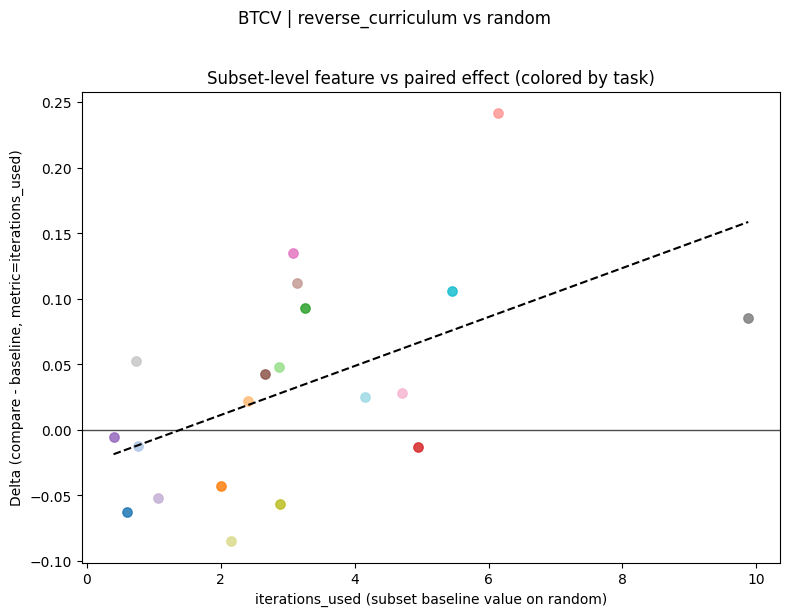

In [ ]:
subset_xy = task_xy
subset_spearman = subset_xy['x'].corr(subset_xy['y'], method='spearman')
print(f'Subset-level Spearman(x, y): {subset_spearman:.4f}')

fig, ax = plt.subplots(figsize=(8, 6))
task_ids = sorted(subset_xy['task_id'].unique().tolist())
cmap = plt.cm.get_cmap('tab20', max(1, len(task_ids)))
task_to_color = {task_id: cmap(i) for i, task_id in enumerate(task_ids)}

for task_id, task_subset in subset_xy.groupby('task_id'):
    label = task_id.split('/', 1)[-1]
    ax.scatter(
        task_subset['x'],
        task_subset['y'],
        alpha=0.85,
        s=45,
        color=task_to_color[task_id],
        label=label,
    )

ax.axhline(0.0, color='black', linewidth=1, alpha=0.7)

if ADD_TRENDLINE and len(subset_xy) >= 2:
    x_vals = subset_xy['x'].to_numpy(dtype=float)
    y_vals = subset_xy['y'].to_numpy(dtype=float)
    slope, intercept = np.polyfit(x_vals, y_vals, deg=1)
    line_x = np.linspace(float(x_vals.min()), float(x_vals.max()), 100)
    line_y = slope * line_x + intercept
    ax.plot(line_x, line_y, linestyle='--', linewidth=1.5, color='black', label='linear trend')

ax.set_xlabel(f'{X_FEATURE} (subset baseline value on {BASELINE_POLICY})')
ax.set_ylabel(f'Delta (compare - baseline, metric={EFFECT_METRIC})')
ax.set_title('Subset-level feature vs paired effect (colored by task)')

# if len(task_ids) <= 20:
#     ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=8)

plt.suptitle(
    f"{DATASET or 'ALL'} | {COMPARE_POLICY} vs {BASELINE_POLICY}",
    y=1.02,
)
plt.tight_layout()
plt.show()


In [ ]:
if EXPORT_TASK_XY:
    if OUTPUT_CSV is None:
        dataset_tag = (DATASET or 'all').lower()
        out_dir = REPO_ROOT / 'figures' / 'policy_xy_builders'
        out_dir.mkdir(parents=True, exist_ok=True)
        output_csv = out_dir / (
            f'{PROCEDURE}_{ABLATION}_{dataset_tag}_{BASELINE_POLICY}_{COMPARE_POLICY}_{X_FEATURE}_{EFFECT_METRIC}_task_xy.csv'
        )
    else:
        output_csv = Path(OUTPUT_CSV)
        output_csv.parent.mkdir(parents=True, exist_ok=True)

    task_xy.to_csv(output_csv, index=False)
    print(f'Wrote {output_csv}')
else:
    print('EXPORT_TASK_XY=False; set True to write task_xy CSV.')


EXPORT_TASK_XY=False; set True to write task_xy CSV.
